# 한국어 → 영어 Attentional Seq2seq 번역기

> **학습 목표**
> - 텍스트 데이터 전처리 (한글 형태소 분석 포함)
> - Bahdanau Attention 기반 Seq2seq 모델 구현
> - Training Loss가 안정적으로 감소하며 학습됨을 확인
> - 테스트 예문 4개에 대해 번역 결과 및 Attention Map 시각화


## 0. 라이브러리 설치 및 임포트

In [1]:
# 필요한 패키지 설치
# - sentencepiece: 서브워드 토크나이저 (필요 시 사용)
# - konlpy       : 한국어 형태소 분석기 (Mecab 포함)
!pip install konlpy


In [2]:
import os, re, tarfile, urllib.request, random, time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

# matplotlib 폰트 경고 억제
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 한글 폰트 설정 (NanumBarunGothic)
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(fontpath):
    fontprop = fm.FontProperties(fname=fontpath, size=11)
    plt.rcParams["font.family"] = fontprop.get_name()
    print(f"폰트 설정 완료: {fontprop.get_name()}")

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch 버전:", torch.__version__)


폰트 설정 완료: NanumBarunGothic
Device: cuda
PyTorch 버전: 2.7.1+cu118


## Step 1. 데이터 다운로드

[jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)
에서 한영 병렬 말뭉치를 다운로드합니다.

- `.ko` 파일: 한국어 문장
- `.en` 파일: 대응하는 영어 문장


In [3]:
# 저장 경로 생성
DATA_DIR = os.path.expanduser("~/work/노드실습/GoingDeeper/5.seq2seq/s2s_translation/kor_eng")
os.makedirs(DATA_DIR, exist_ok=True)

tar_path = os.path.join(DATA_DIR, "korean-english-park.train.tar.gz")

# ── 방법 1: raw.githubusercontent.com 직접 다운로드 ──────────────────────
# Jupyter 환경에서는 아래 URL로 직접 다운로드가 가능합니다.
# 막혀 있을 경우 방법 2(수동)를 사용하세요.
url = (
    "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora"
    "/master/korean-english-news-v1/korean-english-park.train.tar.gz"
)

if not os.path.exists(tar_path):
    print("데이터 다운로드 중... (실패 시 방법 2 사용)")
    try:
        urllib.request.urlretrieve(url, tar_path)
        print("다운로드 완료!")
    except Exception as e:
        print(f"다운로드 실패: {e}")
        print("\n[ 방법 2: 수동 다운로드 ]")
        print("아래 URL에서 파일을 직접 다운로드하여")
        print(f"{DATA_DIR} 경로에 넣어주세요.")
        print(url)
else:
    print("이미 다운로드된 파일 사용")

# ── 압축 해제 ─────────────────────────────────────────────────────────────
# tar.gz 안에 .ko(한국어)와 .en(영어) 파일이 들어 있습니다.
if os.path.exists(tar_path):
    print("압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    print("압축 해제 완료!")
    print("파일 목록:", os.listdir(DATA_DIR))
else:
    print("tar.gz 파일이 없습니다. 수동으로 다운로드 후 다시 실행하세요.")

이미 다운로드된 파일 사용
압축 해제 중...


/tmp/ipykernel_2052/1787803964.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


압축 해제 완료!
파일 목록: ['korean-english-park.train.en', 'korean-english-park.train.ko', 'korean-english-park.train.tar.gz']


## Step 2. 데이터 정제

### 2-1. 원본 데이터 로드


In [4]:
# 한국어 / 영어 파일 경로
kor_file = os.path.join(DATA_DIR, "korean-english-park.train.ko")
eng_file = os.path.join(DATA_DIR, "korean-english-park.train.en")

# 줄 단위로 읽기
with open(kor_file, "r", encoding="utf-8") as f:
    kor_lines = f.read().strip().split("\n")
with open(eng_file, "r", encoding="utf-8") as f:
    eng_lines = f.read().strip().split("\n")

print(f"원본 데이터 수: {len(kor_lines):,}개")
print("\n한국어 예시:", kor_lines[0])
print("영어   예시:", eng_lines[0])


원본 데이터 수: 94,123개

한국어 예시: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
영어   예시: Much of personal computing is about "can you top this?"


### 2-2. 전처리 함수 정의

In [5]:
def preprocess_english(sentence):
    """
    영어 문장 전처리
    1. 소문자 변환
    2. 구두점(?.!,) 앞뒤에 공백 추가  → 토큰으로 분리되도록
    3. 연속 공백 제거
    4. 영문자와 구두점 외 문자 제거
    """
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)   # 구두점 분리
    sentence = re.sub(r'[" "]+', " ", sentence)           # 연속 공백 제거
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)  # 허용 문자 외 제거
    return sentence.strip()


def preprocess_korean(sentence):
    """
    한국어 문장 전처리
    1. 앞뒤 공백 제거
    2. 구두점 앞뒤 공백 추가
    3. 한글 · 숫자 · 공백 · 구두점만 허용 (한자, 특수문자 제거)
    4. 연속 공백 정리
    """
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 한글(가-힣), 숫자, 공백, 기본 구두점만 허용
    sentence = re.sub(r"[^가-힣0-9 ?.!,]+", " ", sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence.strip()


print("전처리 함수 정의 완료!")
print("영어 예시:", preprocess_english(eng_lines[0]))
print("한국어 예시:", preprocess_korean(kor_lines[0]))


전처리 함수 정의 완료!
영어 예시: much of personal computing is about can you top this ?
한국어 예시: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?


### 2-3. 중복 제거

In [6]:
# set을 이용해 (한국어, 영어) 쌍의 중복을 제거
# → 동일한 문장 쌍이 여러 번 나오는 경우 한 번만 유지
seen = set()
cleaned_corpus = []

for kor, eng in zip(kor_lines, eng_lines):
    pair = (kor.strip(), eng.strip())
    # 빈 문장 제외 & 중복 제외
    if pair not in seen and pair[0] and pair[1]:
        seen.add(pair)
        cleaned_corpus.append(pair)

print(f"원본: {len(kor_lines):,}개 → 중복 제거 후: {len(cleaned_corpus):,}개")

# 전처리 적용
cleaned_corpus = [
    (preprocess_korean(k), preprocess_english(e))
    for k, e in cleaned_corpus
]
# 전처리 후 빈 문장 쌍 제거
cleaned_corpus = [(k, e) for k, e in cleaned_corpus if k and e]
print(f"전처리 후: {len(cleaned_corpus):,}개")


원본: 94,123개 → 중복 제거 후: 78,941개
전처리 후: 78,922개


### 2-4. 한글 형태소 분석 (KoNLPy Mecab)

In [7]:
# KoNLPy의 Mecab을 이용한 한국어 형태소 분석
# Mecab은 한국어를 의미 있는 최소 단위(형태소)로 분리해줍니다.
# 예) "나는 학교에 간다" → ["나", "는", "학교", "에", "간다"]
try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    def tokenize_korean(sentence):
        return mecab.morphs(sentence)   # 형태소 단위 토큰화
    print("✅ Mecab 형태소 분석기 로드 완료!")
    print("예시:", tokenize_korean("오바마는 대통령이다."))
except Exception as e:
    print(f"⚠️  Mecab 없음 ({e}) → 공백 기준 토큰화로 대체")
    def tokenize_korean(sentence):
        return sentence.split()


def tokenize_english(sentence):
    """
    영어 토큰화
    - <start> 토큰: 디코더가 문장 생성을 시작할 때 첫 입력으로 사용
    - <end>   토큰: 문장 생성이 끝났음을 알리는 신호
    """
    return ["<start>"] + sentence.split() + ["<end>"]


⚠️  Mecab 없음 (The MeCab dictionary does not exist at "/usr/local/lib/mecab/dic/mecab-ko-dic". Is the dictionary correctly installed?
You can also try entering the dictionary path when initializing the Mecab class: "Mecab('/some/dic/path')") → 공백 기준 토큰화로 대체


### 2-5. 길이 40 이하 필터링

In [8]:
# 너무 긴 문장은 학습에 방해가 되므로 토큰 수 40 이하인 쌍만 사용
MAX_LEN = 40
kor_corpus, eng_corpus = [], []

for kor, eng in cleaned_corpus:
    kor_tokens = tokenize_korean(kor)
    eng_tokens = tokenize_english(eng)
    if len(kor_tokens) <= MAX_LEN and len(eng_tokens) <= MAX_LEN:
        kor_corpus.append(kor_tokens)
        eng_corpus.append(eng_tokens)

print(f"길이 필터링 후 최종 데이터 수: {len(kor_corpus):,}개")
print("\n한국어 토큰 예시:", kor_corpus[0])
print("영어   토큰 예시:", eng_corpus[0])


길이 필터링 후 최종 데이터 수: 70,141개

한국어 토큰 예시: ['개인용', '컴퓨터', '사용의', '상당', '부분은', '이것보다', '뛰어날', '수', '있느냐', '?']
영어   토큰 예시: ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


## Step 3. 단어 사전(Vocabulary) 구축

단어 ↔ 인덱스 매핑을 관리하는 클래스  
특수 토큰:
| 토큰 | 용도 |
|------|------|
| `<pad>` | 배치 내 길이를 맞추기 위한 패딩 |
| `<start>` | 디코더 입력의 시작 신호 |
| `<end>` | 문장 종료 신호 |
| `<unk>` | 사전에 없는 단어 처리 |


In [9]:
class Vocabulary:
    def __init__(self, special_tokens=["<pad>", "<start>", "<end>", "<unk>"]):
        # 특수 토큰을 0번부터 순서대로 할당
        self.word2idx = {tok: i for i, tok in enumerate(special_tokens)}
        self.idx2word = {i: tok for i, tok in enumerate(special_tokens)}
        # 자주 사용하는 특수 토큰 ID를 속성으로 저장
        self.pad_id = self.word2idx["<pad>"]
        self.bos_id = self.word2idx["<start>"]
        self.eos_id = self.word2idx["<end>"]
        self.unk_id = self.word2idx["<unk>"]

    def build(self, corpus, min_freq=2):
        """
        말뭉치에서 단어 빈도를 세고, min_freq 이상인 단어만 사전에 추가
        min_freq=2 → 1번만 등장하는 희귀 단어는 <unk>로 처리 (일반화 향상)
        """
        from collections import Counter
        counter = Counter(tok for sent in corpus for tok in sent)
        for word, freq in counter.items():
            if freq >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f"사전 크기: {len(self.word2idx):,}")

    def encode(self, tokens):
        """토큰 리스트 → 인덱스 리스트 (사전에 없으면 unk_id)"""
        return [self.word2idx.get(t, self.unk_id) for t in tokens]

    def decode(self, ids):
        """인덱스 리스트 → 토큰 리스트"""
        return [self.idx2word.get(i, "<unk>") for i in ids]

    def __len__(self):
        return len(self.word2idx)


# 한국어 / 영어 사전 각각 구축
kor_vocab = Vocabulary()
eng_vocab = Vocabulary()
kor_vocab.build(kor_corpus, min_freq=2)
eng_vocab.build(eng_corpus, min_freq=2)

print(f"\n한국어 사전 크기: {len(kor_vocab):,}")
print(f"영어   사전 크기: {len(eng_vocab):,}")


사전 크기: 69,181
사전 크기: 26,573

한국어 사전 크기: 69,181
영어   사전 크기: 26,573


## Step 3-2. Dataset & DataLoader

In [10]:
class TranslationDataset(Dataset):
    def __init__(self, kor_corpus, eng_corpus, kor_vocab, eng_vocab, max_len):
        self.data      = list(zip(kor_corpus, eng_corpus))
        self.kor_vocab = kor_vocab
        self.eng_vocab = eng_vocab
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        kor_tokens, eng_tokens = self.data[idx]

        # 한국어 인코딩 (최대 길이로 자르기)
        src_ids = self.kor_vocab.encode(kor_tokens)[:self.max_len]

        # 영어 인코딩 (이미 <start>/<end> 포함)
        trg_ids = self.eng_vocab.encode(eng_tokens)

        # ┌─ Teacher Forcing을 위한 입력/레이블 분리 ─────────────────────┐
        # trg_input : <start> w1 w2 ... wn      (마지막 토큰 제외)
        # trg_label :         w1 w2 ... wn <end> (첫 토큰 제외)
        # → 디코더가 t번째 입력을 받아 t+1번째 단어를 예측하도록 학습
        # └────────────────────────────────────────────────────────────────┘
        trg_input = trg_ids[:-1][:self.max_len]
        trg_label = trg_ids[1:][:self.max_len]

        # 패딩: max_len 길이로 맞추기 (짧은 문장 뒤에 <pad> 추가)
        pad = self.kor_vocab.pad_id
        src_ids   = src_ids   + [pad]                    * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.eng_vocab.pad_id]  * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.eng_vocab.pad_id]  * (self.max_len - len(trg_label))

        return (torch.tensor(src_ids),
                torch.tensor(trg_input),
                torch.tensor(trg_label))


BATCH_SIZE = 64
dataset     = TranslationDataset(kor_corpus, eng_corpus, kor_vocab, eng_vocab, MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"전체 데이터: {len(dataset):,}개")
print(f"배치 크기: {BATCH_SIZE}, 배치 수: {len(train_loader)}")

# 샘플 확인
src, trg_in, trg_lb = next(iter(train_loader))
print(f"\nsrc shape      : {src.shape}      → (batch, src_len)")
print(f"trg_input shape: {trg_in.shape}  → (batch, trg_len)")
print(f"trg_label shape: {trg_lb.shape}  → (batch, trg_len)")


전체 데이터: 70,141개
배치 크기: 64, 배치 수: 1095

src shape      : torch.Size([64, 40])      → (batch, src_len)
trg_input shape: torch.Size([64, 40])  → (batch, trg_len)
trg_label shape: torch.Size([64, 40])  → (batch, trg_len)


## Step 4. 모델 설계

### Bahdanau Attention

**핵심 아이디어**: 디코더가 매 스텝마다 인코더의 모든 hidden state에  
"얼마나 집중할지"를 동적으로 계산

In [11]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # 인코더 hidden state를 변환하는 가중치 행렬 W1
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        # 디코더 hidden state를 변환하는 가중치 행렬 W2
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        # 정렬 점수(alignment score)를 스칼라로 압축하는 벡터 v
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        """
        hidden          : (batch, hidden_dim)          - 디코더의 이전 hidden state
        encoder_outputs : (src_len, batch, hidden_dim) - 인코더 전체 출력
        반환값           : attention weights (batch, src_len)
        """
        src_len = encoder_outputs.shape[0]

        # 디코더 hidden을 src_len 방향으로 복제 → 인코더 각 위치와 비교 가능하게
        h = hidden.unsqueeze(1).repeat(1, src_len, 1)   # (batch, src_len, hidden)
        enc = encoder_outputs.permute(1, 0, 2)          # (batch, src_len, hidden)

        # 정렬 에너지 계산: tanh(W1*h_j + W2*s_{t-1})
        energy = torch.tanh(self.W1(enc) + self.W2(h))  # (batch, src_len, hidden)

        # 스칼라 점수로 압축 후 softmax → 확률 분포(합이 1)
        attention = self.v(energy).squeeze(2)            # (batch, src_len)
        return torch.softmax(attention, dim=1)           # (batch, src_len)


### Encoder (GRU 기반)

In [12]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.3):
        """
        input_dim  : 입력 어휘 크기 (한국어 vocab size)
        emb_dim    : 임베딩 차원 (단어를 벡터로 표현하는 차원 수)
        hidden_dim : GRU hidden state 차원
        dropout    : 과적합 방지를 위한 드롭아웃 비율
        """
        super().__init__()
        # 단어 인덱스 → 밀집 벡터 (padding_idx=0: 패딩 토큰은 학습하지 않음)
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        # GRU: LSTM보다 파라미터 수가 적고 학습이 빠름
        # batch_first=False → 입력 shape: (seq_len, batch, feature)
        self.rnn       = nn.GRU(emb_dim, hidden_dim, batch_first=False)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        """
        src     : (src_len, batch)
        returns : outputs (src_len, batch, hidden_dim),
                  hidden  (1, batch, hidden_dim)
        """
        # 드롭아웃을 적용한 임베딩
        embedded = self.dropout(self.embedding(src))    # (src_len, batch, emb)
        # GRU 통과
        outputs, hidden = self.rnn(embedded)
        # outputs : 모든 타임스텝의 hidden state → Attention에 사용
        # hidden  : 마지막 타임스텝의 hidden state → 디코더 초기 상태
        return outputs, hidden


### Decoder (GRU + Bahdanau Attention)

In [13]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.3):
        """
        output_dim : 출력 어휘 크기 (영어 vocab size)
        attention  : BahdanauAttention 인스턴스
        """
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        # GRU 입력: 임베딩만 받음 (context vector는 출력층에서 결합)
        self.rnn       = nn.GRU(emb_dim, hidden_dim)
        # 출력층: hidden state + context vector 결합 → vocab 크기로 투영
        self.fc_out    = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        """
        input           : (batch,)                     - 현재 스텝 입력 토큰
        hidden          : (1, batch, hidden_dim)       - 이전 스텝 hidden state
        encoder_outputs : (src_len, batch, hidden_dim) - 인코더 전체 출력
        """
        # (batch,) → (1, batch) → 임베딩 적용
        input    = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))  # (1, batch, emb)

        # ① Attention: 현재 디코더 hidden으로 인코더 각 위치의 가중치 계산
        a = self.attention(hidden[-1], encoder_outputs) # (batch, src_len)

        # ② Context Vector: 인코더 출력의 가중 합
        a   = a.unsqueeze(1)                            # (batch, 1, src_len)
        enc = encoder_outputs.permute(1, 0, 2)          # (batch, src_len, hidden)
        context = torch.bmm(a, enc).permute(1, 0, 2)   # (1, batch, hidden)

        # ③ GRU: 임베딩만 입력, hidden 업데이트
        output, hidden = self.rnn(embedded, hidden)     # output: (1, batch, hidden)

        # ④ 출력층: hidden + context 결합으로 단어 예측
        out        = output.squeeze(0)                  # (batch, hidden)
        ctx        = context.squeeze(0)                 # (batch, hidden)
        prediction = self.fc_out(torch.cat([out, ctx], dim=1))  # (batch, vocab)

        return prediction, hidden, a.squeeze(1)         # attention weight도 반환


### Seq2Seq (Encoder + Decoder 결합)

In [14]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg=None, max_len=40, bos_id=1, eos_id=2):
        """
        학습 시 (trg 제공)   : Teacher Forcing - 정답 토큰을 디코더 입력으로 사용
        추론 시 (trg=None)   : 이전 예측 토큰을 다음 입력으로 사용 (자기회귀)
        """
        batch_size = src.shape[1]
        outputs, attentions = [], []

        # 인코더 실행: 입력 문장 전체를 처리해 hidden state 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # ── 학습 모드 (Teacher Forcing) ──────────────────────────────
            # trg의 각 타임스텝을 순서대로 디코더에 입력
            for t in range(trg.shape[0]):
                out, hidden, attn = self.decoder(trg[t], hidden, encoder_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
        else:
            # ── 추론 모드 (자기회귀 생성) ─────────────────────────────────
            # 첫 입력은 <start> 토큰
            inp      = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for _ in range(max_len):
                out, hidden, attn = self.decoder(inp, hidden, encoder_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                # 가장 높은 확률의 단어를 다음 입력으로
                top1 = out.argmax(1)
                inp  = top1
                # <end> 토큰이 나오면 해당 배치 완료 표시
                finished |= (top1 == eos_id)
                if finished.all():   # 모든 배치가 완료되면 조기 종료
                    break

        outputs    = torch.cat(outputs,    dim=0)  # (trg_len, batch, vocab)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch, src_len)
        return outputs, attentions


# ── 모델 인스턴스 생성 ────────────────────────────────────────────────────
EMB_DIM = 256   # 임베딩 차원
HID_DIM = 512   # GRU hidden 차원

encoder   = Encoder(len(kor_vocab), EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder   = Decoder(len(eng_vocab), EMB_DIM, HID_DIM, attention).to(device)
model     = Seq2SeqAttention(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\n학습 가능한 파라미터 수: {total_params:,}")


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(69181, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(26573, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=26573, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

학습 가능한 파라미터 수: 54,641,613


## Step 5. 훈련

### Optimizer & Loss 설정

- **Adam**: 학습률 자동 조정 옵티마이저 (lr=1e-3)
- **CrossEntropyLoss**: 다중 분류 손실 함수  
  - `ignore_index=pad_id` → 패딩 위치는 손실 계산에서 제외


In [15]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ignore_index: 패딩 토큰(0)에 대한 loss는 계산하지 않음
# → 패딩이 많은 짧은 문장이 학습을 왜곡하지 않도록
criterion = nn.CrossEntropyLoss(ignore_index=kor_vocab.pad_id)

print("Optimizer:", optimizer.__class__.__name__)
print("Loss     : CrossEntropyLoss (ignore_index=0)")


Optimizer: Adam
Loss     : CrossEntropyLoss (ignore_index=0)


### train_step 함수

In [16]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    """
    한 에폭 전체를 학습하고 평균 손실을 반환합니다.

    핵심 흐름:
    1. src, trg_input, trg_label을 (seq_len, batch) 형태로 변환
    2. 모델 순전파 → 예측값 계산
    3. CrossEntropyLoss로 손실 계산
    4. 역전파 & 파라미터 업데이트
    5. Gradient Clipping으로 기울기 폭발 방지
    """
    model.train()
    epoch_loss = 0

    for src, trg_input, trg_label in data_loader:
        # (batch, seq_len) → (seq_len, batch): PyTorch RNN 기본 입력 형태
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()  # 이전 배치의 기울기 초기화

        # Teacher Forcing으로 학습
        outputs, _ = model(src, trg_input)  # (trg_len, batch, vocab)

        # CrossEntropyLoss 입력 형태에 맞게 reshape
        # (trg_len, batch, vocab) → (trg_len*batch, vocab)
        outputs   = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        # Gradient Clipping: 기울기 노름이 1을 초과하면 스케일 다운
        # → RNN 학습 시 흔히 발생하는 기울기 폭발(gradient explosion) 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(data_loader)  # 배치 수로 나눈 평균 손실


### 훈련 시작

In [17]:
EPOCHS = 20
train_losses = []

print("===== 훈련 시작 =====")
start = time.time()

for epoch in range(EPOCHS):
    loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  Train Loss: {loss:.4f}")

elapsed = time.time() - start
print(f"\n총 훈련 시간: {elapsed:.1f}초 ({elapsed/60:.1f}분)")


===== 훈련 시작 =====
Epoch  1/20  |  Train Loss: 5.6059
Epoch  2/20  |  Train Loss: 4.6664
Epoch  3/20  |  Train Loss: 4.1133
Epoch  4/20  |  Train Loss: 3.7080
Epoch  5/20  |  Train Loss: 3.4175
Epoch  6/20  |  Train Loss: 3.2144
Epoch  7/20  |  Train Loss: 3.0612
Epoch  8/20  |  Train Loss: 2.9370
Epoch  9/20  |  Train Loss: 2.8367
Epoch 10/20  |  Train Loss: 2.7513
Epoch 11/20  |  Train Loss: 2.6783
Epoch 12/20  |  Train Loss: 2.6119
Epoch 13/20  |  Train Loss: 2.5539
Epoch 14/20  |  Train Loss: 2.5011
Epoch 15/20  |  Train Loss: 2.4531
Epoch 16/20  |  Train Loss: 2.4119
Epoch 17/20  |  Train Loss: 2.3697
Epoch 18/20  |  Train Loss: 2.3322
Epoch 19/20  |  Train Loss: 2.2974
Epoch 20/20  |  Train Loss: 2.2633

총 훈련 시간: 8154.8초 (135.9분)


### Training Loss 시각화

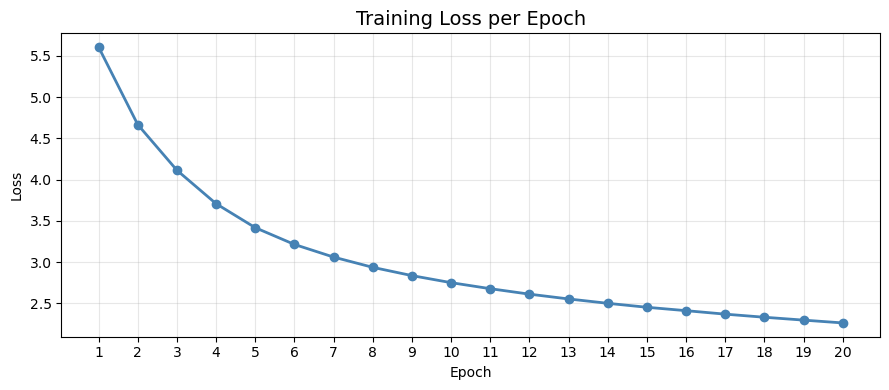

Loss 그래프 저장: train_loss.png


In [18]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='steelblue', linewidth=2)
plt.title("Training Loss per Epoch", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCHS + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("train_loss.png", dpi=100)
plt.show()
print("Loss 그래프 저장: train_loss.png")


## Step 6. 번역 및 Attention Map 시각화

학습된 모델로 한국어 문장을 영어로 번역하고,  
Attention Map을 통해 모델이 어떤 입력 토큰에 집중했는지 시각화


In [19]:
def evaluate(sentence, model, kor_vocab, eng_vocab, max_len=40):
    """
    한국어 문장 하나를 전처리 → 토큰화 → 인코딩 → 추론 순으로 처리합니다.
    반환:
        result     : 예측된 영어 토큰 리스트
        src_tokens : 입력 한국어 형태소 리스트 (Attention 시각화에 사용)
        attention  : (trg_len, src_len) numpy 배열
    """
    model.eval()
    sentence   = preprocess_korean(sentence)
    tokens     = tokenize_korean(sentence)

    # 인덱스 변환 + 패딩
    src_ids    = kor_vocab.encode(tokens)[:max_len]
    src_ids    = src_ids + [kor_vocab.pad_id] * (max_len - len(src_ids))

    # (max_len,) → (max_len, 1): 배치 차원 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(
            src_tensor, max_len=max_len,
            bos_id=eng_vocab.bos_id, eos_id=eng_vocab.eos_id
        )

    # argmax로 각 스텝의 예측 단어 선택
    pred_ids = outputs.argmax(2).squeeze(1).tolist()
    result   = eng_vocab.decode(pred_ids)

    # <end> 토큰 이후는 제거
    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, tokens, attentions.squeeze(1).cpu().numpy()


def plot_attention(attention, src_tokens, pred_tokens, title=""):
    """
    Attention Map 히트맵 시각화
    - x축: 입력(한국어) 토큰
    - y축: 출력(영어) 토큰
    - 색이 밝을수록 해당 입력 토큰에 더 많이 집중함
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    # 실제 예측 길이 / 입력 길이만큼 잘라서 시각화
    attn_slice = attention[:len(pred_tokens), :len(src_tokens)]
    ax.matshow(attn_slice, cmap="viridis")
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90, fontsize=11)
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens, fontsize=11)
    ax.set_xlabel("입력 (한국어)", labelpad=10)
    ax.set_ylabel("출력 (영어)")
    ax.set_title(f"Attention Map: {title}", fontsize=13, pad=15)
    plt.tight_layout()
    plt.savefig(f"attention_{title[:8]}.png", dpi=100)
    plt.show()


def translate(sentence, model, kor_vocab, eng_vocab, max_len=40):
    result, src_tokens, attention = evaluate(sentence, model, kor_vocab, eng_vocab, max_len)
    print(f"입력 (한국어): {sentence}")
    print(f"번역 (영어)  : {' '.join(result)}")
    plot_attention(attention, src_tokens, result, title=sentence)
    return result


### 테스트 예문 번역

입력 (한국어): 오바마는 대통령이다.
번역 (영어)  : obama has been charged with illinois .


/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

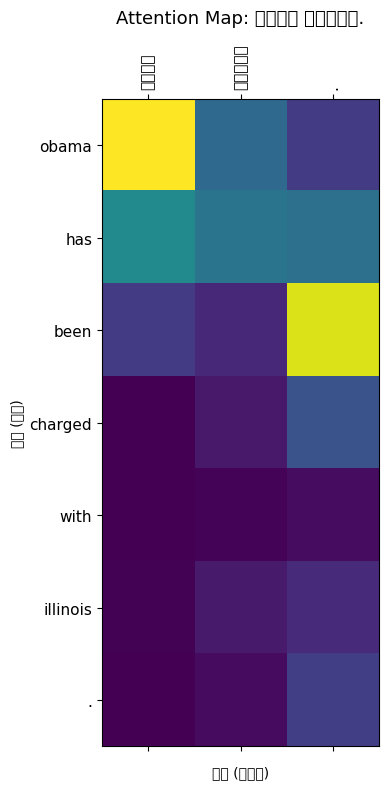

/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

--------------------------------------------------
입력 (한국어): 시민들은 도시 속에 산다.
번역 (영어)  : the urban areas is in the city of mosul .


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46308 (\N{HANGUL SYLLABLE DEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/c

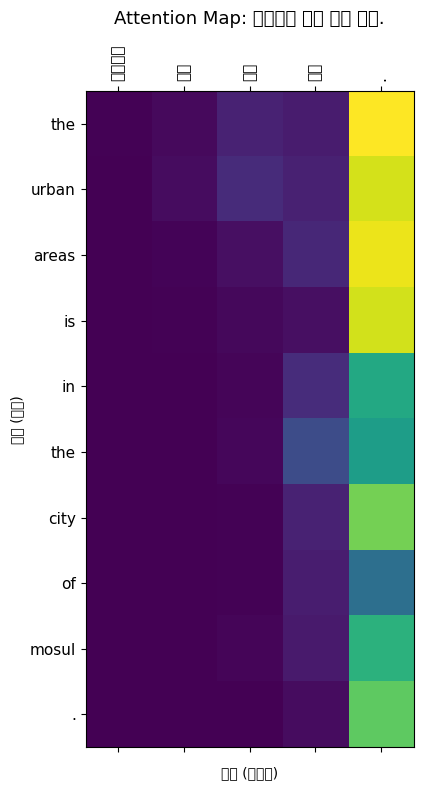

/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


--------------------------------------------------
입력 (한국어): 커피는 필요 없다.
번역 (영어)  : no reason for the next few days .


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/c

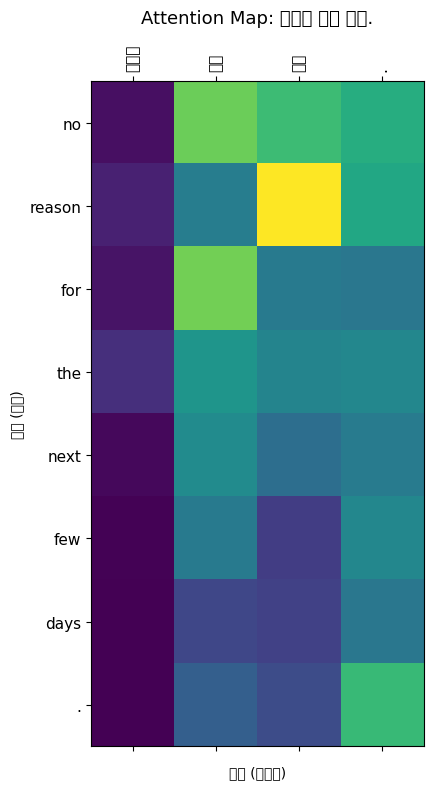

/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2052/156159615.py:55: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

--------------------------------------------------
입력 (한국어): 일곱 명의 사망자가 발생했다.
번역 (영어)  : seven hundred people were killed and another were wounded .


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/

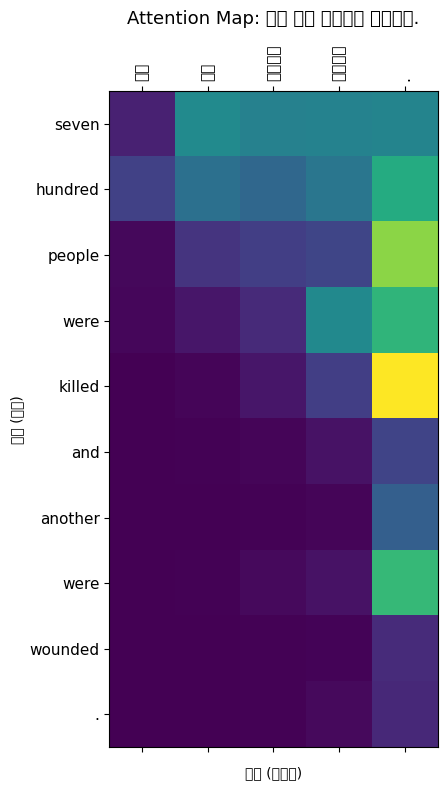

--------------------------------------------------


In [20]:
# 루브릭에 제시된 테스트 예문 4개
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

print("=" * 50)
for sent in test_sentences:
    translate(sent, model, kor_vocab, eng_vocab)
    print("-" * 50)
